In [103]:
from typing import NamedTuple
import math
import pandas as pd
import seaborn as sns
import seaborn.objects as so

In [104]:
sns.set_style("white")

In [105]:
class Claim(NamedTuple):
    label: str
    description: str
    prior: float
    fde: float


The claims

C1
: There is a family of elephants living in the refrigerator in my kitchen.

C2
: There are some stars with planets orbiting them in the galaxy BX422.

C3
: There is a forth planet around the millionth brightest star in BX422 on which there is a family of African elephants living in a refrigerator.

C4
: Ignoring air resistance, a heavier object will fall faster than a lighter one.


In [106]:
c1 = Claim(label = "C1",
            description="There is a family of elephants living in"
              " the refrigerator in my kitchen,",
            prior = 1e-6,
            fde = 0.99)
c2 = Claim(label = "C2",
            description="There are some stars with planets orbiting them in the galaxy BX422.",
            prior = 0.95,
            fde = 5e-6)
c3 = Claim(label="C3",
           description="There is a forth planet around the millionth brightest"
             " star in BX422 on which there is a family of African elephants" 
             " living in a refrigerator.",
            prior = 1e-9,
            fde = 1e-8)

c4 = Claim(label="C4",
           description="Ignoring air resistance, a heavier object"
            " will fall faster than a lighter one.",
            prior = 0.9,
            fde = 0.99)


Now we see if I can manage Pandas dataframses


In [107]:
claims =  {c.label: c for c in [c1, c2, c3, c4]}
claims

{'C1': Claim(label='C1', description='There is a family of elephants living in the refrigerator in my kitchen,', prior=1e-06, fde=0.99),
 'C2': Claim(label='C2', description='There are some stars with planets orbiting them in the galaxy BX422.', prior=0.95, fde=5e-06),
 'C3': Claim(label='C3', description='There is a forth planet around the millionth brightest star in BX422 on which there is a family of African elephants living in a refrigerator.', prior=1e-09, fde=1e-08),
 'C4': Claim(label='C4', description='Ignoring air resistance, a heavier object will fall faster than a lighter one.', prior=0.9, fde=0.99)}

In [108]:
df = pd.DataFrame.from_dict(claims, orient="index")
df

,label,description,prior,fde
C1,C1,There is a family of elephants living in the r...,1.000000e-06,9.900000e-01
C2,C2,There are some stars with planets orbiting the...,9.500000e-01,5.000000e-06
C3,C3,There is a forth planet around the millionth b...,1.000000e-09,1.000000e-08
C4,C4,"Ignoring air resistance, a heavier object will...",9.000000e-01,9.900000e-01


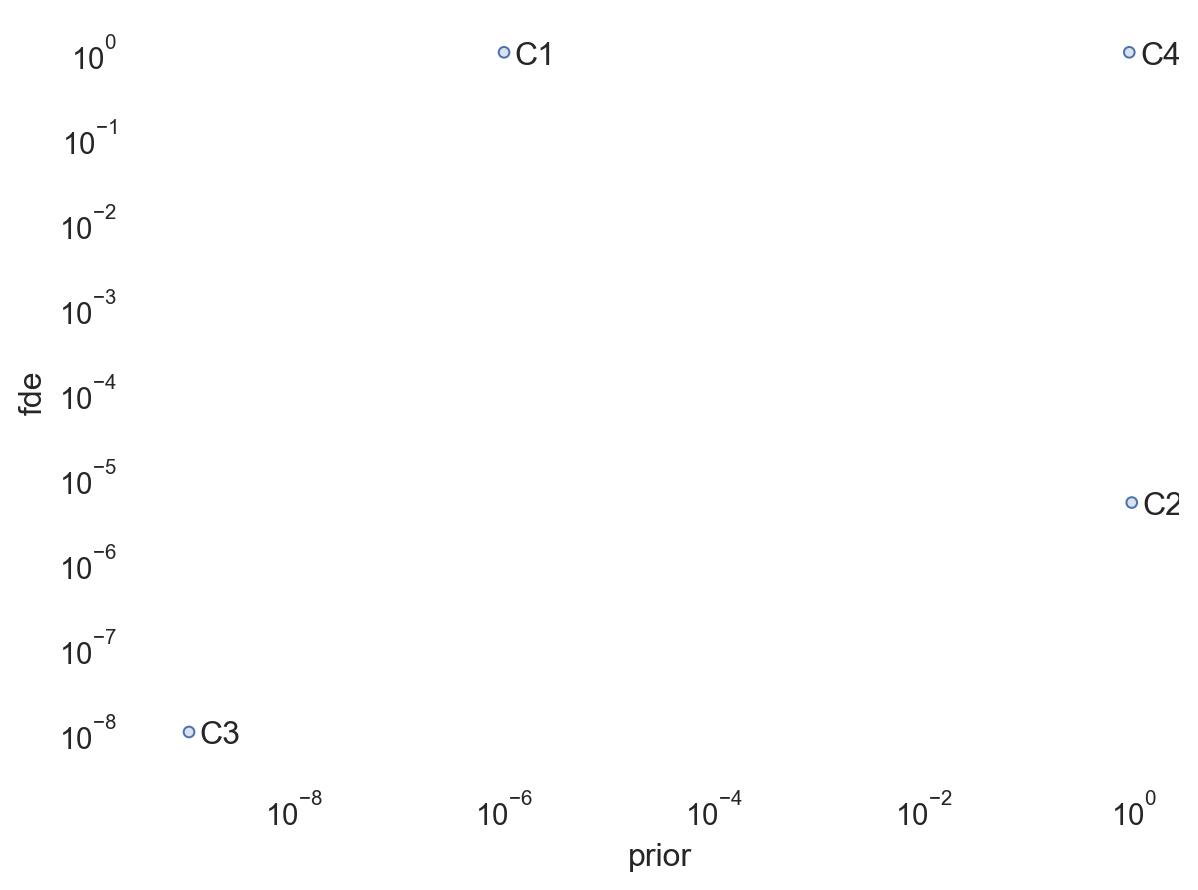

In [119]:
p = (
    so.Plot(df, x="prior", y="fde", text="label")
      .add(so.Dots())
      .add(so.Text(halign="left")).scale(y='log', x='log')
      .theme({"axes.facecolor": "w"})
)
p

